In [2]:
import pandas as pd
import dask.dataframe as dd

In [3]:
tf = pd.read_csv("Trips_Full Data.csv")

In [4]:
td = pd.read_csv("Trips_by_Distance.csv")

In [5]:
td.columns = (td.columns.str.strip().str.lower().str.replace(" ","_"))
td = td.fillna(td.mean(numeric_only=True)) # fills missing numeric values with its mean 

In [6]:
# handles missing categorical values
td["state_postal_code"] = td["state_postal_code"].fillna("Unknown")
td["county_name"] = td["county_name"].fillna("Unknown")

In [7]:
tf.columns = (tf.columns.str.strip().str.lower().str.replace(" ","_"))  

In [8]:
td.dtypes

level                              object
date                               object
state_fips                        float64
state_postal_code                  object
county_fips                       float64
county_name                        object
population_staying_at_home        float64
population_not_staying_at_home    float64
number_of_trips                   float64
number_of_trips_<1                float64
number_of_trips_1-3               float64
number_of_trips_3-5               float64
number_of_trips_5-10              float64
number_of_trips_10-25             float64
number_of_trips_25-50             float64
number_of_trips_50-100            float64
number_of_trips_100-250           float64
number_of_trips_250-500           float64
number_of_trips_>=500             float64
row_id                             object
week                                int64
month                               int64
dtype: object

In [9]:
td["date"] = pd.to_datetime(td["date"])

In [10]:
tf["date"] = pd.to_datetime(tf["date"])

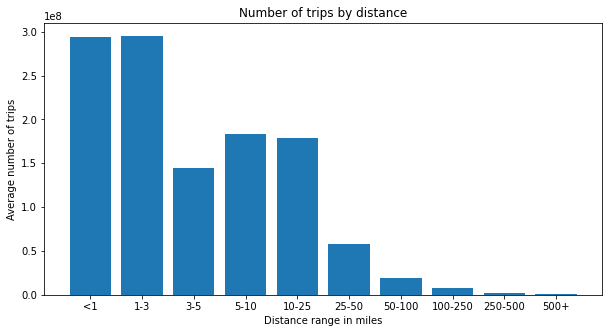

In [37]:
import matplotlib.pyplot as plt

national_data = td[td["level"] == "National"]

distance_means = {
    "<1": national_data["number_of_trips_<1"].mean(),
    "1-3": national_data["number_of_trips_1-3"].mean(),
    "3-5": national_data["number_of_trips_3-5"].mean(),
    "5-10": national_data["number_of_trips_5-10"].mean(),
    "10-25": national_data["number_of_trips_10-25"].mean(),
    "25-50": national_data["number_of_trips_25-50"].mean(),
    "50-100": national_data["number_of_trips_50-100"].mean(),
    "100-250": national_data["number_of_trips_100-250"].mean(),
    "250-500": national_data["number_of_trips_250-500"].mean(),
    "500+": national_data["number_of_trips_>=500"].mean()
}

plt.figure(figsize=(10,5))
plt.bar(distance_means.keys(), distance_means.values())
plt.xlabel("Distance range in miles")
plt.ylabel("Average number of trips")
plt.title("Number of trips by distance")
plt.xticks(rotation=0)
plt.show()